# Logistics Shipments Dataset 

## Data Exploration

#### This notebook explores the raw logistics dataset used for the analytics project.

#### The goal of this step is to understand the structure of the dataset, identify potential data quality issues, and determine the cleaning steps required before building the analytical model.

### Objectives:
 - Understand the structure of the dataset
 - Identify missing values and duplicates
 - Analyze the main variables related to shipments
 - Detect potential inconsistencies in the data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Loading the dataset
df = pd.read_csv("../data/raw/shipments_raw.csv")

df.head()

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  str    
 2   PQ #                          10324 non-null  str    
 3   PO / SO #                     10324 non-null  str    
 4   ASN/DN #                      10324 non-null  str    
 5   Country                       10324 non-null  str    
 6   Managed By                    10324 non-null  str    
 7   Fulfill Via                   10324 non-null  str    
 8   Vendor INCO Term              10324 non-null  str    
 9   Shipment Mode                 9964 non-null   str    
 10  PQ First Sent to Client Date  10324 non-null  str    
 11  PO Sent to Vendor Date        10324 non-null  str    
 12  Scheduled Delivery Date       10324 non-null  str    
 13  Delivered to

In [3]:
df.describe()

,ID,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Line Item Insurance (USD)
count,10324.000000,10324.000000,10324.000000,1.032400e+04,10324.000000,10324.000000,10037.000000
mean,51098.968229,77.990895,18332.534870,1.576506e+05,21.910241,0.611701,240.117626
std,31944.332496,76.579764,40035.302961,3.452921e+05,45.609223,3.275808,500.190568
min,1.000000,1.000000,1.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,12795.750000,30.000000,408.000000,4.314593e+03,4.120000,0.080000,6.510000
50%,57540.500000,60.000000,3000.000000,3.047147e+04,9.300000,0.160000,47.040000
75%,83648.250000,90.000000,17039.750000,1.664471e+05,23.592500,0.470000,252.400000
max,86823.000000,1000.000000,619999.000000,5.951990e+06,1345.640000,238.650000,7708.440000


### Observations:

The dataset contains shipment-level information including shipment mode,
cost, insurance values, and destination data.

The shipment cost distribution shows large variability, suggesting that
different shipment modes or routes may significantly affect costs.

Some columns contain missing values that will need to be addressed during
the data cleaning stage.

In [ ]:
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": missing_pct
}).query("`Missing Count` > 0").sort_values("Missing %", ascending=False)

,Missing Count,Missing %
Dosage,1736,16.82
Shipment Mode,360,3.49
Line Item Insurance (USD),287,2.78


### Missing Values:

These values will need to be handled during the cleaning phase. Possible
strategies include imputation or removal depending on analytical relevance.

In [5]:
df.duplicated().sum()

np.int64(0)

### Duplicates:

No duplicate rows found across all 10,324 records. 

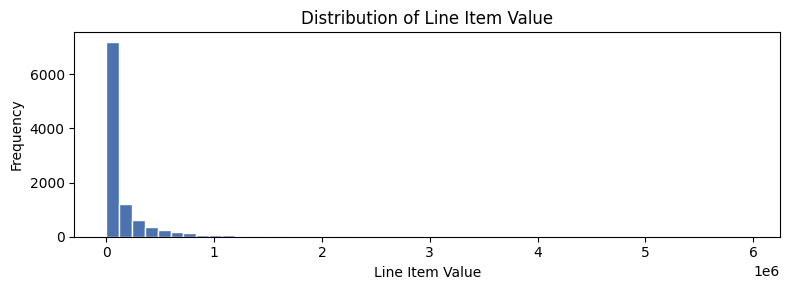

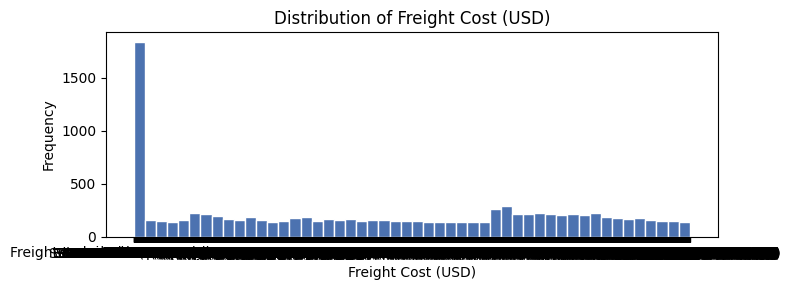

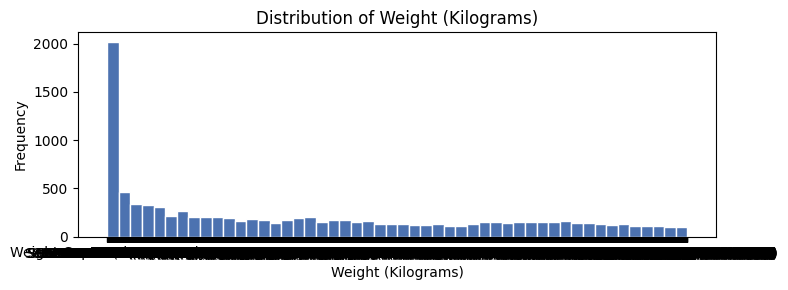

In [6]:
columns = [
    "Line Item Value",
    "Freight Cost (USD)",
    "Weight (Kilograms)"
]

for col in columns:
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.hist(df[col].dropna(), bins=50, color="#4C72B0", edgecolor="white")
    ax.set_title(f"Distribution of {col}", fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## Key Findings

The exploratory analysis identified several data quality issues:

- Missing values in shipment mode, dosage, and insurance columns
- Wide distribution in shipment values
- Some columns type str shoud be datetime:
    - `Scheduled Delivery Date`
    - `Delivered to Client Date`
    - `Delivery Recorded Date`
- Two columns contain text and date values
    - `PQ First Sent to Client Date`
    - `PO Sent to Vendor Date`
- Data quality inspection revealed that in the columns `Weight (Kilograms)` and `Freight Cost (USD)` some rows contained textual references
  such as `"See ASN-93 (ID#:1281)"` or administrative notes like `Weight Captured Separately`, `Freight Included in Commodity Cost`.
  These values indicate that the corresponding weight or freight cost was
  recorded in a different record or external document. 

These issues will be addressed in the next stage of the project: data cleaning.

### The next notebook will focus on cleaning and transforming the dataset, including:

- Handling missing values
- Standardizing column names
- Preparing the dataset for feature engineering